# Notebook 01: Isotherm Fitting (Synthetic Test Data)

This notebook generates synthetic data from a chosen isotherm model, adds noise, and fits multiple candidate models.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

from utils_isotherms import (
    MODELS,
    generate_synthetic_data,
    compute_SSE, compute_R2, compute_AIC, compute_BIC,
    compute_EABS, compute_RESID, compute_ARED, compute_MPSED, compute_HYBRID,
)

In [5]:
# --- Helper functions for fitting ---
def initial_guess(model_name, Ce, qe):
    # Basic, robust starting guesses based on data scale
    qmax = float(np.nanmax(qe)) if len(qe) else 1.0
    ce_med = float(np.nanmedian(Ce)) if len(Ce) else 1.0
    ce_med = max(ce_med, 1e-8)
    if model_name == 'Langmuir':
        return [qmax, 1.0 / ce_med]
    if model_name == 'Freundlich':
        return [max(qmax / ce_med, 1e-6), 0.6]
    if model_name == 'Sips':
        return [qmax, 1.0 / ce_med, 0.8]
    if model_name == 'Toth':
        return [qmax, 1.0 / ce_med, 0.8]
    if model_name == 'Jovanovic':
        return [qmax, 1.0 / ce_med]
    if model_name == 'Hill':
        return [qmax, 1.0, 1.0]
    return None

def bounds_for(model_name):
    # Conservative bounds to avoid invalid powers/logs
    if model_name in ['Langmuir', 'Jovanovic']:
        return (0, np.inf)
    if model_name == 'Freundlich':
        # KF > 0, 1/n in (0, 2) to keep Ce**(1/n) stable
        return ([0, 0.05], [np.inf, 2.0])
    if model_name == 'Sips':
        # Qmax > 0, KS > 0, m in (0.1, 2)
        return ([0, 0, 0.1], [np.inf, np.inf, 2.0])
    if model_name == 'Toth':
        # Qmax > 0, b > 0, t in (0.1, 2)
        return ([0, 0, 0.1], [np.inf, np.inf, 2.0])
    if model_name == 'Hill':
        # Qmax > 0, KD > 0, nH in (0.1, 4)
        return ([0, 0, 0.1], [np.inf, np.inf, 4.0])
    return (0, np.inf)


## Generate synthetic data from a selected model

Choose a model and parameters below. The defaults are reasonable starting points.


In [6]:
# Select which model to generate
model_name = 'Langmuir'  # Options: Langmuir, Freundlich, Sips, Toth, Jovanovic, Hill

# Default parameters for synthetic generation
default_params = {
    'Langmuir': (50, 0.8),
    'Freundlich': (10, 0.6),
    'Sips': (60, 0.6, 0.8),
    'Toth': (60, 0.8, 0.7),
    'Jovanovic': (60, 0.7),
    'Hill': (60, 1.0, 1.2),
}

if model_name not in default_params:
    raise ValueError(f'No default parameters for {model_name}. Add them above.')

model_func = MODELS[model_name][0]
params = default_params[model_name]

Ce, q_exp, q_true = generate_synthetic_data(
    model_func,
    params,
    Ce_range=(0.1, 100),
    n_points=20,
    noise_level=0.05,
    seed=42,
)

print(f'Generated data using {model_name} with params={params}')


Generated data using Langmuir with params=(50, 0.8)


## Fit candidate isotherm models


In [7]:
# Select models to fit
model_names = [
    'Langmuir', 'Freundlich', 'Sips', 'Toth', 'Jovanovic', 'Hill'
]

# Always reset results to a list (prevents accidental type reuse)
results = []
n = len(Ce)

for model_name in model_names:
    func, param_names, p = MODELS[model_name]
    p0 = initial_guess(model_name, Ce, q_exp)
    bounds = bounds_for(model_name)
    try:
        with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
            popt, _ = curve_fit(func, Ce, q_exp, p0=p0, bounds=bounds, maxfev=20000)
            q_pred = func(Ce, *popt)
        sse = compute_SSE(q_exp, q_pred)
        r2 = compute_R2(q_exp, q_pred)
        aic = compute_AIC(n, sse, p)
        bic = compute_BIC(n, sse, p)
        eabs = compute_EABS(q_exp, q_pred)
        resid = compute_RESID(q_exp, q_pred)
        ared = compute_ARED(q_exp, q_pred)
        mpsed = compute_MPSED(q_exp, q_pred)
        hybrid = compute_HYBRID(q_exp, q_pred, p)
        results.append({
            'model': model_name,
            'params': popt,
            'param_names': param_names,
            'SSE': sse,
            'R2': r2,
            'AIC': aic,
            'BIC': bic,
            'EABS': eabs,
            'RESID': resid,
            'ARED': ared,
            'MPSED': mpsed,
            'HYBRID': hybrid,
            'func': func,
            'q_pred': q_pred,
        })
    except Exception as e:
        results.append({
            'model': model_name,
            'params': None,
            'param_names': param_names,
            'SSE': np.nan,
            'R2': np.nan,
            'AIC': np.nan,
            'BIC': np.nan,
            'EABS': np.nan,
            'RESID': np.nan,
            'ARED': np.nan,
            'MPSED': np.nan,
            'HYBRID': np.nan,
            'func': func,
            'q_pred': None,
            'error': str(e),
        })

summary = pd.DataFrame([{
    'Model': r['model'],
    'SSE': r['SSE'],
    'R2': r['R2'],
    'AIC': r['AIC'],
    'BIC': r['BIC'],
    'EABS': r['EABS'],
    'RESID': r['RESID'],
    'ARED': r['ARED'],
    'MPSED': r['MPSED'],
    'HYBRID': r['HYBRID'],
} for r in results])
summary.sort_values('AIC', inplace=True)
summary


,Model,SSE,R2,AIC,BIC,EABS,RESID,ARED,MPSED,HYBRID
0,Langmuir,31.866203,0.994306,13.316274,15.307738,19.323932,0.966197,3.544810,0.128293,4.910374
3,Toth,29.620021,0.994707,13.854365,16.841562,19.233110,0.961656,4.071612,0.115308,5.364451
2,Sips,30.442074,0.994560,14.401868,17.389064,19.719792,0.985990,4.229955,0.142737,5.555159
5,Hill,30.442074,0.994560,14.401868,17.389064,19.719791,0.985990,4.229955,0.142737,5.555159
4,Jovanovic,94.874900,0.983046,35.136538,37.128003,38.083396,1.904170,10.571013,0.444710,24.738383
1,Freundlich,1011.628092,0.819224,82.471680,84.463145,126.579506,6.328975,47.024479,4.040028,456.841427


## Plot experimental data and top model fits


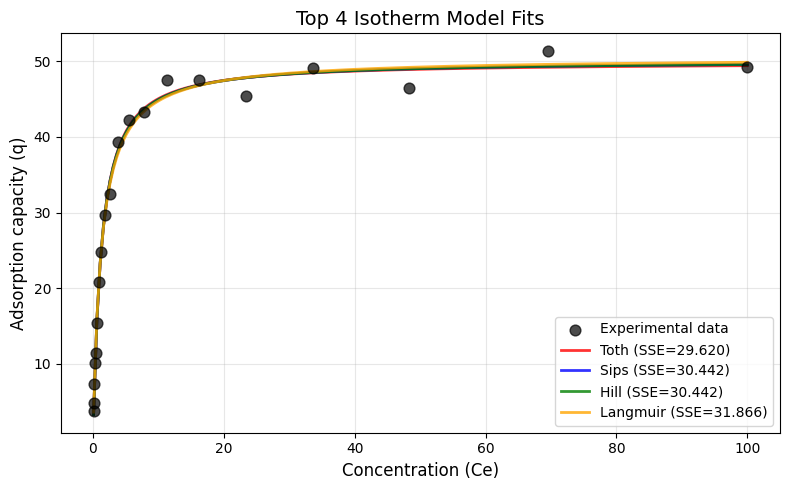

In [8]:
# Plot experimental data and top 4 model fits (by SSE)
plt.figure(figsize=(8, 5))

plt.scatter(Ce, q_exp, color='black', label='Experimental data', s=60, alpha=0.7, zorder=5)

sorted_results = sorted(results, key=lambda x: x['SSE'])
top_4_results = [r for r in sorted_results if r['q_pred'] is not None][:4]

colors = ['red', 'blue', 'green', 'orange']
for i, result in enumerate(top_4_results):
    Ce_smooth = np.linspace(Ce.min(), Ce.max(), 200)
    q_smooth = result['func'](Ce_smooth, *result['params'])
    plt.plot(
        Ce_smooth,
        q_smooth,
        color=colors[i],
        linewidth=2,
        label=f"{result['model']} (SSE={result['SSE']:.3f})",
        alpha=0.8,
    )

plt.xlabel('Concentration (Ce)', fontsize=12)
plt.ylabel('Adsorption capacity (q)', fontsize=12)
plt.title('Top 4 Isotherm Model Fits', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
